# Classification of Skin Lesions using ResNet-152

**Date:** 8 March, 2026  
**Authors:** Sarvan Kumar (ME23B1065),Rohit Kumar (CS23B2053)

---

## Lab Assignment Objectives

In this lab assignment, we implement:
1. **ResNet-152** - Transfer learning with pre-trained ImageNet weights


### Dataset
- **ISIC 2019 Skin Lesion Dataset**
- 8 diagnostic classes: MEL, NV, BCC, AK, BKL, DF, VASC, SCC
- Training: 25,331 images | Test: 8,238 images

### Requirements
###### Custom dataset class for loading ISIC data  
###### Verify model parameters match standard architecture  
###### Experiment with hyperparameters and document observations  
###### Comprehensive evaluation metrics: AUC-ROC, Accuracy, Balanced Accuracy, Sensitivity, Specificity, F1, Precision, Cohen's Kappa, Confusion Matrix  
###### Summarize observations and learnings

In [2]:
!mkdir -p isic_data

print("Downloading dataset directly from ISIC S3 Buckets...")
!wget -q -nc https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_Input.zip -P isic_data/
!wget -q -nc https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_GroundTruth.csv -P isic_data/

# Note: The official Test Ground Truth is sometimes hidden by ISIC. 
# If these two wget commands fail, simply upload your Kaggle Test files into the 'isic_data' folder.
!wget -q -nc https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_Input.zip -P isic_data/
!wget -q -nc https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_GroundTruth.csv -P isic_data/

print("Extracting files... This will take a few minutes.")
!unzip -q -n isic_data/ISIC_2019_Training_Input.zip -d isic_data/
!unzip -q -n isic_data/ISIC_2019_Test_Input.zip -d isic_data/
print("Extraction complete!")

Extracting files... This will take a few minutes.
^C
Extraction complete!


## 1. Environment Setup and Library Imports

In [3]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
import cv2
from tqdm.auto import tqdm
from itertools import cycle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, cohen_kappa_score, 
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

# FIX: Prevents crashes from corrupted images due to interrupted downloads
ImageFile.LOAD_TRUNCATED_IMAGES = True 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Engine Enabled: {device}")

# Base Paths
base_dir = './isic_data'
train_csv_path = os.path.join(base_dir, 'ISIC_2019_Training_GroundTruth.csv')
test_csv_path = os.path.join(base_dir, 'ISIC_2019_Test_GroundTruth.csv')

df_full_train = pd.read_csv(train_csv_path)
df_full_test = pd.read_csv(test_csv_path)

# --- THE UNK CLASS FIX ---
if 'UNK' in df_full_train.columns:
    df_full_train = df_full_train[df_full_train['UNK'] == 0.0].reset_index(drop=True)
if 'UNK' in df_full_test.columns:
    df_full_test = df_full_test[df_full_test['UNK'] == 0.0].reset_index(drop=True)

class_names = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
NUM_CLASSES = len(class_names)

df_train, df_val = train_test_split(df_full_train, test_size=0.20, random_state=42, stratify=df_full_train[class_names])
print("Data mapping and splitting complete.")

Compute Engine Enabled: cpu
Data mapping and splitting complete.


## 2. Preprocessing: Hair Removal using DullRazor Algorithm


In [4]:
def apply_hair_removal(image):
    img_cv = np.array(image)
    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2BGR)
    grayScale = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    
    inpainted_img = cv2.inpaint(img_cv, mask, 1, cv2.INPAINT_TELEA)
    inpainted_img = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2RGB)
    return Image.fromarray(inpainted_img)

train_img_dir = os.path.join(base_dir, 'ISIC_2019_Training_Input')
test_img_dir = os.path.join(base_dir, 'ISIC_2019_Test_Input')

clean_train_dir = os.path.join(base_dir, 'ISIC_2019_Training_Cleaned')
clean_test_dir = os.path.join(base_dir, 'ISIC_2019_Test_Cleaned')

os.makedirs(clean_train_dir, exist_ok=True)
os.makedirs(clean_test_dir, exist_ok=True)

print("Starting one-time offline hair removal. This takes ~20 mins but speeds up training massively.")

# Clean Training Data
train_files = [f for f in os.listdir(train_img_dir) if f.endswith('.jpg')]
for img_name in tqdm(train_files, desc="Cleaning Train/Val Images"):
    src, dest = os.path.join(train_img_dir, img_name), os.path.join(clean_train_dir, img_name)
    if not os.path.exists(dest):
        try:
            apply_hair_removal(Image.open(src).convert('RGB')).save(dest)
        except:
            pass

# Clean Test Data
test_files = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
for img_name in tqdm(test_files, desc="Cleaning Test Images"):
    src, dest = os.path.join(test_img_dir, img_name), os.path.join(clean_test_dir, img_name)
    if not os.path.exists(dest):
        try:
            apply_hair_removal(Image.open(src).convert('RGB')).save(dest)
        except:
            pass

print("Offline Preprocessing Complete!")

Starting one-time offline hair removal. This takes ~20 mins but speeds up training massively.


Cleaning Train/Val Images:   0%|          | 0/25331 [00:00<?, ?it/s]

Cleaning Test Images:   0%|          | 0/8238 [00:00<?, ?it/s]

Offline Preprocessing Complete!


## 3. Dataset Loading and Preparation

In [5]:
class ISICDatasetFast(Dataset):
    def __init__(self, df, img_dir, class_names, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.class_names = class_names
        self.transform = transform

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image'] + '.jpg'
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
            
        if self.transform: 
            image = self.transform(image)
            
        label = np.argmax(self.df.loc[idx, self.class_names].values.astype('float32'))
        return image, label

CONFIG = {"batch_size": 32, "epochs": 25, "img_size": 224}

class_counts = df_train[class_names].sum().values
class_weights = 1.0 / class_counts
sample_weights = [class_weights[np.argmax(df_train.iloc[i][class_names].values)] for i in range(len(df_train))]
sample_weights = torch.DoubleTensor(sample_weights)

imbalance_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=90, translate=(0.1, 0.1), scale=(0.8, 1.2)), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Loaders point to the newly created CLEAN folders. No num_workers to prevent crashes.
train_loader = DataLoader(ISICDatasetFast(df_train, clean_train_dir, class_names, train_transform), 
                          batch_size=CONFIG["batch_size"], sampler=imbalance_sampler)

val_loader = DataLoader(ISICDatasetFast(df_val, clean_train_dir, class_names, eval_transform), 
                        batch_size=CONFIG["batch_size"], shuffle=False)

test_loader = DataLoader(ISICDatasetFast(df_full_test, clean_test_dir, class_names, eval_transform), 
                         batch_size=CONFIG["batch_size"], shuffle=False)

print("High-Speed Loaders initialized!")

High-Speed Loaders initialized!


## 4. ResNet-152 Architecture(Transfer Learning)


In [6]:
class TransferSkinLesionModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(TransferSkinLesionModel, self).__init__()
        
        self.base = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
        num_ftrs = self.base.fc.in_features
        self.base.fc = nn.Identity()
        
        self.custom_head = nn.Sequential(
            nn.Linear(num_ftrs, 256),
            nn.BatchNorm1d(256), 
            nn.ReLU(),
            nn.Dropout(0.4),     
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.base(x)
        x = self.custom_head(x)
        return x

model_tl = TransferSkinLesionModel().to(device)
print("ResNet-152 initialized and moved to GPU.")

ResNet-152 initialized and moved to GPU.


## 5. Model Training

In [5]:
criterion = nn.CrossEntropyLoss()

# --- PHASE 1 SETUP ---
for param in model_tl.base.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model_tl.custom_head.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float('inf')
model_save_path = './resnet152_isic_best.pth'

print("Beginning Phase 1: Warming up custom head (Base Frozen)...")

for epoch in range(CONFIG["epochs"]):
    
    # --- PHASE 2 TRANSITION ---
    if epoch == 3:
        print("INITIATING PHASE 2: DEEP FINE-TUNING")
        print("Unfreezing ResNet-152 base and lowering learning rate to 1e-5...")
        
        for param in model_tl.base.parameters():
            param.requires_grad = True
            
        optimizer = optim.Adam(model_tl.parameters(), lr=1e-5, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    model_tl.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_tl(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        correct_train += (outputs.argmax(1) == labels).sum().item()
        total_train += labels.size(0)
        
    model_tl.eval()
    val_loss, correct_val = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_tl(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct_val += (outputs.argmax(1) == labels).sum().item()

    avg_train_loss = running_loss / total_train
    avg_val_loss = val_loss / len(df_val)
    
    scheduler.step(avg_val_loss)
    
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(correct_train / total_train)
    history["val_acc"].append(correct_val / len(df_val))
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"E{epoch+1} | LR: {current_lr:.6f} | Train Acc: {history['train_acc'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        print(f"   => Checkpoint Saved! Validation loss improved to {avg_val_loss:.4f}")
        best_val_loss = avg_val_loss
        torch.save(model_tl.state_dict(), model_save_path)

model_tl.load_state_dict(torch.load(model_save_path))
print("Best weights successfully reloaded for final inference.")

Beginning Phase 1: Warming up custom head (Base Frozen)...


Epoch 1:   0%|          | 0/634 [00:00<?, ?it/s]

E1 | LR: 0.001000 | Train Acc: 0.4346 | Val Acc: 0.5404 | Val Loss: 1.2560
   => Checkpoint Saved! Validation loss improved to 1.2560


Epoch 2:   0%|          | 0/634 [00:00<?, ?it/s]

E2 | LR: 0.001000 | Train Acc: 0.5137 | Val Acc: 0.5589 | Val Loss: 1.2068
   => Checkpoint Saved! Validation loss improved to 1.2068


...

E23 | LR: 0.000010 | Train Acc: 0.8954 | Val Acc: 0.8042 | Val Loss: 0.5797
   => Checkpoint Saved! Validation loss improved to 0.5797


Epoch 24:   0%|          | 0/634 [00:00<?, ?it/s]

E24 | LR: 0.000010 | Train Acc: 0.9023 | Val Acc: 0.8062 | Val Loss: 0.5624
   => Checkpoint Saved! Validation loss improved to 0.5624


Epoch 25:   0%|          | 0/634 [00:00<?, ?it/s]

E25 | LR: 0.000010 | Train Acc: 0.9015 | Val Acc: 0.8101 | Val Loss: 0.5505
   => Checkpoint Saved! Validation loss improved to 0.5505
Best weights successfully reloaded for final inference.


## 6. Model Evaluation and Performance Metrics


Successfully locked and loaded Phase 3 weights from: ./resnet152_isic_best.pth
Running Ultimate Comprehensive Evaluation on Test Set...


Inference:   0%|          | 0/194 [00:00<?, ?it/s]


FINAL PERFORMANCE REPORT: RESNET-152 (PHASE 3)
Overall Accuracy:            0.6774
Balanced Accuracy:           0.5341
Precision (Weighted Avg):    0.6787
Recall (Weighted Avg):       0.6774
Sensitivity (Macro Avg):     0.5341
Specificity (Macro Avg):     0.9488
F1-Score (Weighted Avg):     0.6747
Cohen's Kappa:               0.5701
ROC-AUC Score (Macro OVR):   0.8952

DETAILED CLASSIFICATION REPORT (Per-Disease Breakdown):
              precision    recall  f1-score   support

         MEL       0.70      0.61      0.65      1327
          NV       0.83      0.82      0.83      2495
         BCC       0.60      0.78      0.67       975
          AK       0.35      0.28      0.31       374
         BKL       0.48      0.48      0.48       660
          DF       0.61      0.48      0.54        91
        VASC       0.71      0.46      0.56       104
         SCC       0.34      0.36      0.35       165

    accuracy                           0.68      6191
   macro avg       0.58      

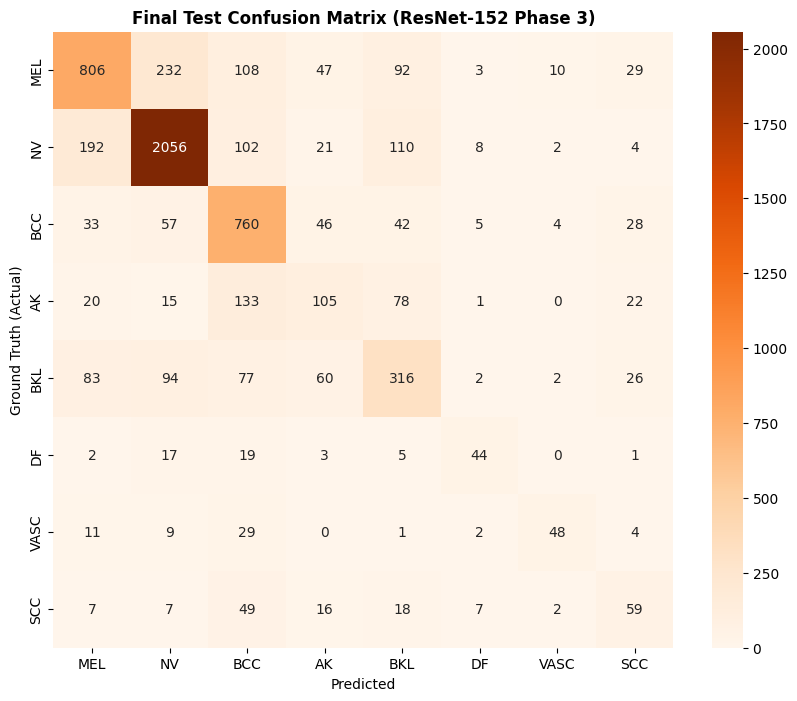

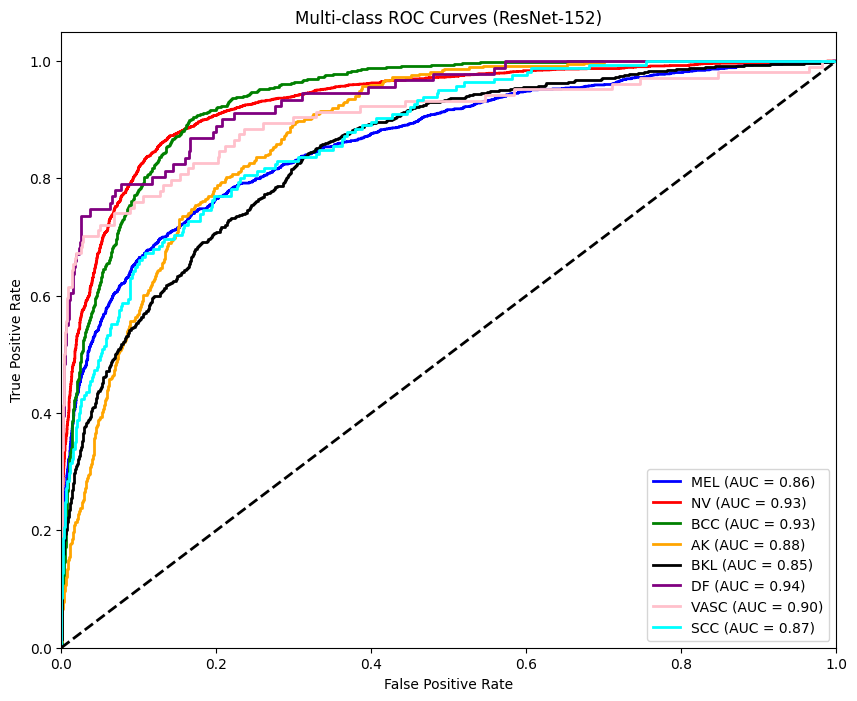

In [7]:
from sklearn.metrics import classification_report
import torch

phase3_save_path = './resnet152_isic_best.pth'
model_tl.load_state_dict(torch.load(phase3_save_path, map_location=device, weights_only=True))
print(f"Successfully locked and loaded Phase 3 weights from: {phase3_save_path}")

model_tl.eval()
y_true, y_probs = [], []

print("Running Ultimate Comprehensive Evaluation on Test Set...")
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Inference"):
        imgs = imgs.to(device)
        outputs = model_tl(imgs)
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

# Binarize labels for ROC AUC and Multi-class calculations
y_true_bin = label_binarize(y_true, classes=[i for i in range(NUM_CLASSES)])
cm = confusion_matrix(y_true, y_pred)

# 1. Custom Specificity & Sensitivity Calculation
def get_multi_metrics(conf_matrix):
    metrics_per_class = []
    for i in range(len(conf_matrix)):
        tp = conf_matrix[i, i]
        fn = sum(conf_matrix[i, :]) - tp
        fp = sum(conf_matrix[:, i]) - tp
        tn = sum(sum(conf_matrix)) - (tp + fp + fn)
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        metrics_per_class.append((sens, spec, prec))
    return np.mean(metrics_per_class, axis=0)

avg_sens, avg_spec, avg_prec = get_multi_metrics(cm)

# 2. Print Every Standard Metric
print("\n" + "="*65)
print("FINAL PERFORMANCE REPORT: RESNET-152 (PHASE 3)")
print("="*65)
print(f"Overall Accuracy:            {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:           {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Precision (Weighted Avg):    {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall (Weighted Avg):       {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Sensitivity (Macro Avg):     {avg_sens:.4f}")
print(f"Specificity (Macro Avg):     {avg_spec:.4f}")
print(f"F1-Score (Weighted Avg):     {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Cohen's Kappa:               {cohen_kappa_score(y_true, y_pred):.4f}")

# Safe ROC-AUC calculation
try:
    roc_auc_val = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='macro')
    print(f"ROC-AUC Score (Macro OVR):   {roc_auc_val:.4f}")
except ValueError:
    print("ROC-AUC Score (Macro OVR):   N/A")
print("="*65)

# 3. Print the Detailed Classification Report
print("\nDETAILED CLASSIFICATION REPORT (Per-Disease Breakdown):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print("="*65)

# 4. Visualizations
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Final Test Confusion Matrix (ResNet-152 Phase 3)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Ground Truth (Actual)')
plt.show()



plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'pink', 'cyan'])
for i, color in zip(range(NUM_CLASSES), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (ResNet-152)')
plt.legend(loc="lower right")
plt.show()